# Part 1A — Classification ML Pipeline

**Question:** can measured tumour characteristics classify the recorded diagnosis in scikit-learn's bundled breast-cancer dataset?

**Classification** predicts a category. This notebook teaches the complete workflow: split, build a pipeline, cross-validate, compare against a baseline, evaluate once, and state the limits.

> **Teaching boundary:** this is an educational benchmark. It is **not** clinical decision support, screening guidance, or deployment evidence. Part 0 explains why the supplied healthcare CSV is used for description rather than for this benchmark.

**Roadmap:** load → inspect → split → pipeline → cross-validate → evaluate once → categorical preprocessing → interpret limits.

## 0. Before you begin

**Runtime:** about 5 minutes of computation; about an hour with discussion. The cross-validation cell is the slowest because it fits each pipeline five times.

**Data:** `load_breast_cancer()` ships with scikit-learn. No upload and no network download. Section 7 optionally reads the course CSV.

**If anything breaks:** restart the kernel and use **Run All**. Do not create missing variables by hand.

In [1]:
import platform

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
                             balanced_accuracy_score, classification_report, f1_score,
                             make_scorer, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")

print(f"Python: {platform.python_version()} | scikit-learn: {sklearn.__version__}")

Python: 3.13.5 | scikit-learn: 1.6.1


## 1. Load and inspect the bundled dataset

A **feature** is an input column. The **target** is the recorded value we ask the model to predict.

**Look for:** the number of features and observations, how the target numbers map to names, and whether the classes are balanced.

Documentation: [`load_breast_cancer`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html).

In [2]:
dataset = load_breast_cancer(as_frame=True)
X = dataset.data.copy()
y = dataset.target.copy()
target_names = list(dataset.target_names)

print(f"Features: {X.shape[1]} | observations: {X.shape[0]}")
print(f"Target mapping: {dict(enumerate(target_names))}")

display(X.head())

class_counts = y.map(dict(enumerate(target_names))).value_counts().to_frame("count")
class_counts["percent"] = (class_counts["count"] / len(y) * 100).round(1)
display(class_counts)

Features: 30 | observations: 569
Target mapping: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,count,percent
target,,
benign,357,62.7
malignant,212,37.3


### What do we see?

569 observations and 30 numeric features, all measurements taken from the same images.

The classes are **not** balanced: roughly 63% `benign` and 37% `malignant`. That number is the bar to beat. A model that always predicted `benign` would score 63% accuracy while never identifying a single malignant case.

This is exactly why accuracy alone is a poor choice here, and why we will use macro F1 and a confusion matrix instead.

## 2. Split before fitting anything

Reserve 20% of rows as a **held-out test set**. It is used once, at the very end.

`stratify=y` keeps the class proportions roughly the same in both parts, which matters when classes are unbalanced.

> **Do not use the test set to choose anything.** Model selection happens on the training portion only. Using test data to pick a model turns the final number into an optimistic estimate of itself.

Documentation: [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "training %": (y_train.value_counts(normalize=True).sort_index() * 100).round(1),
    "test %": (y_test.value_counts(normalize=True).sort_index() * 100).round(1),
})
split_summary.index = [target_names[i] for i in split_summary.index]

print(f"Training rows: {len(X_train)} | test rows: {len(X_test)}")
display(split_summary)

Training rows: 455 | test rows: 114


,training %,test %
malignant,37.4,36.8
benign,62.6,63.2


### What do we see?

The class percentages match closely across the two parts. That is stratification working.

Without it, a random split could easily hand the test set a different class balance from the training set, and the final metric would partly reflect that accident rather than the model.

## 3. Build pipelines

A **`Pipeline`** chains preprocessing steps and a model into one object. This is not a convenience — it is a correctness requirement.

When a pipeline is cross-validated, each fold's preprocessing is fitted **only on that fold's training rows**. If you instead scaled all the data up front, information from the validation rows would leak into the transformation, and your estimate would be optimistic.

The **dummy classifier** is the baseline: it predicts using class frequencies only, ignoring every feature. A model that cannot beat it has learned nothing useful.

Documentation: [`Pipeline`](https://scikit-learn.org/stable/modules/compose.html), [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

In [4]:
preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

dummy_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", DummyClassifier(strategy="prior")),
])

classification_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

print(f"Missing values in this dataset: {int(X.isna().sum().sum())}")
print(classification_pipeline)

Missing values in this dataset: 0
Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])


### What do we see?

The printed pipeline shows the exact order of operations: impute, then scale, then fit the model.

**The imputer is kept even though this dataset has no missing values.** It is there as a robust workflow pattern, because real health data usually does have gaps. Keeping it costs nothing and means the pipeline does not break when it meets data that needs it.

Scaling matters for logistic regression because the model applies a penalty to large coefficients. Without scaling, a feature measured in thousands would be penalised differently from one measured in decimals, purely because of its units.

## 4. Compare workflows with cross-validation on the training data only

**Cross-validation** splits the training portion into five folds, fits on four and validates on the fifth, and repeats so every fold is validated once.

**Macro F1** averages the F1 score of each class equally, so the smaller class counts as much as the larger one.

> **Runtime note:** this cell fits each pipeline five times. Wait for the table before continuing.

Documentation: [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html), [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html).

**Look for:** the gap between the two rows, and the size of the standard deviations.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": make_scorer(f1_score, average="macro"),
}

rows = []
for name, pipeline in {"Dummy prior": dummy_pipeline,
                       "Logistic regression": classification_pipeline}.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)
    row = {"model": name}
    for metric in scoring:
        row[f"{metric} mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric} SD"] = scores[f"test_{metric}"].std()
    rows.append(row)

cv_results = pd.DataFrame(rows).set_index("model").round(3)
display(cv_results)

,accuracy mean,accuracy SD,balanced_accuracy mean,balanced_accuracy SD,f1_macro mean,f1_macro SD
model,,,,,,
Dummy prior,0.626,0.00,0.500,0.000,0.385,0.000
Logistic regression,0.978,0.01,0.975,0.013,0.976,0.011


### What do we see?

Logistic regression reaches about 0.97 macro F1; the dummy baseline reaches about 0.39. The gap is large and the standard deviations are small, so the improvement is consistent across all five folds rather than driven by one lucky split.

Look at the dummy row carefully. Its accuracy is around 0.63 while its macro F1 is around 0.39. **The same predictions produce very different numbers depending on the metric.** A baseline that never finds the malignant class still looks acceptable on accuracy. That is the argument for choosing your metric before you look at results.

We now select logistic regression — using these training-fold numbers only. The test set has still not been touched.

## 5. Evaluate once on the held-out test set

Fit the selected pipeline on all training rows, then predict the test rows one time.

Report errors **by class**, not accuracy alone. A confusion matrix shows which direction the mistakes go, which is the part that matters clinically.

**Look for:** the off-diagonal cells in the matrix — those are the errors.

In [6]:
classification_pipeline.fit(X_train, y_train)
y_pred = classification_pipeline.predict(X_test)

test_scores = pd.Series({
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced accuracy": balanced_accuracy_score(y_test, y_pred),
    "macro F1": f1_score(y_test, y_pred, average="macro"),
}).to_frame("held-out test score").round(3)
display(test_scores)

print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

,held-out test score
accuracy,0.982
balanced accuracy,0.981
macro F1,0.981


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Show the errors as a matrix

The classification report gives per-class numbers. The confusion matrix shows the same information as counts, which makes the direction of each mistake explicit.

**Look for:** the two off-diagonal cells. They are the two different kinds of error.

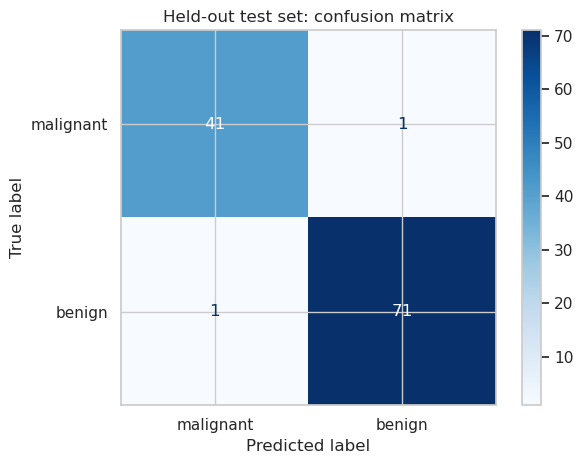

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=target_names, cmap="Blues"
)
plt.title("Held-out test set: confusion matrix")
plt.tight_layout()
plt.show()

### What do we see?

Test performance is close to the cross-validation estimate, which is reassuring: it suggests the workflow did not overfit the training folds.

Read the confusion matrix by row. The bottom-left cell counts cases that were truly `malignant` but predicted `benign` — **false negatives**. The top-right counts `benign` predicted as `malignant` — **false positives**.

These two errors are not equivalent. A missed malignancy and an unnecessary follow-up have very different consequences, and no single number in the table above distinguishes them. That is why the matrix is shown rather than summarised away.

**This is one estimate, on one split, of one dataset.** It does not establish performance on a different population, a different scanner, or a later time period.

## 6. Inspect ranking quality with ROC AUC

**ROC** plots the true-positive rate against the false-positive rate as the decision threshold moves. **AUC** summarises that curve into one number describing how well the model *ranks* cases.

AUC does not tell you calibration, clinical usefulness, or which threshold to use.

Documentation: [`RocCurveDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html).

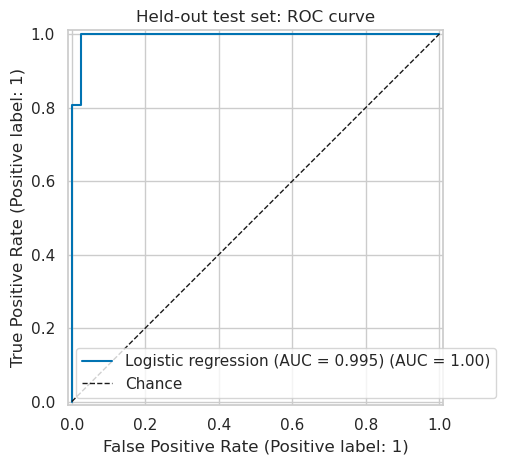

In [8]:
y_score = classification_pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_score)

RocCurveDisplay.from_predictions(y_test, y_score, name=f"Logistic regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
plt.title("Held-out test set: ROC curve")
plt.legend()
plt.tight_layout()
plt.show()

### What do we see?

The curve sits well above the diagonal and AUC is near 1.0, meaning the model ranks almost every malignant case above almost every benign one.

**A common misconception: AUC is not accuracy.** AUC asks "if I draw one case of each class, how often does the model score the malignant one higher?" It says nothing about what happens at any particular threshold, and every real deployment has to pick a threshold.

**Second caution:** high AUC does not mean the predicted probabilities are trustworthy as probabilities. A model can rank perfectly while being badly calibrated. Checking that is a separate exercise — see `../handouts/metric_chooser.md`.

## 7. How categorical health data enters a model

The dataset above is entirely numeric, which is convenient and unrepresentative. Real health data is full of categories: `Admission Type`, `Insurance Provider`, `Medical Condition`, `Blood Type`.

A model cannot accept the text `"Emergency"`. Something has to turn it into numbers, and the choice matters.

**One-hot encoding** creates one new 0/1 column per category. `Admission Type` becomes three columns, exactly one of which is 1 for any given row.

The alternative — numbering categories 1, 2, 3 — would be wrong here. It would tell the model that `Urgent` is greater than `Elective`, and that the gap between them equals the gap between `Elective` and `Emergency`. Neither claim is true.

A **`ColumnTransformer`** applies different preprocessing to different columns: scale the numeric ones, one-hot encode the categorical ones, in a single object that still fits inside a pipeline.

Documentation: [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

In [9]:
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

def find_data_file(filename, max_levels_up=4):
    """Look for a file in the working directory and each folder above it."""
    here = Path.cwd().resolve()
    for directory in [here, *list(here.parents)[:max_levels_up]]:
        candidate = directory / filename
        if candidate.exists():
            return candidate
    return None

CSV_PATH = find_data_file("healthcare_dataset.csv")

if CSV_PATH is None:
    print("Course CSV not found - section 7 is skipped. Everything above still ran.")
else:
    health_df = pd.read_csv(CSV_PATH).drop_duplicates()
    numeric_features = ["Age"]
    categorical_features = ["Gender", "Blood Type", "Medical Condition",
                            "Insurance Provider", "Admission Type"]
    health_X = health_df[numeric_features + categorical_features]

    print(f"Loaded {len(health_df):,} rows. Admission-time columns only:\n")
    for column in categorical_features:
        print(f"  {column:22} {health_df[column].nunique():>2} categories")

Loaded 54,966 rows. Admission-time columns only:

  Gender                  2 categories
  Blood Type              8 categories
  Medical Condition       6 categories
  Insurance Provider      5 categories
  Admission Type          3 categories


### Build the two branches and inspect what the model receives

**Look for:** the number of columns before and after encoding, and the generated feature names.

In [10]:
if CSV_PATH is not None:
    numeric_branch = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_branch = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    column_preprocessor = ColumnTransformer([
        ("numeric", numeric_branch, numeric_features),
        ("categorical", categorical_branch, categorical_features),
    ])

    encoded = column_preprocessor.fit_transform(health_X)
    feature_names = column_preprocessor.get_feature_names_out()

    print(f"Columns supplied to the transformer : {health_X.shape[1]}")
    print(f"Columns produced for the model      : {encoded.shape[1]}\n")

    expansion = pd.DataFrame([
        {"source column": column,
         "categories": health_X[column].nunique(),
         "columns produced": sum(name.startswith(f"categorical__{column}_") for name in feature_names)}
        for column in categorical_features
    ])
    display(expansion)
    print("First 12 generated feature names:")
    for name in feature_names[:12]:
        print(" ", name)

Columns supplied to the transformer : 6
Columns produced for the model      : 25



,source column,categories,columns produced
0,Gender,2,2
1,Blood Type,8,8
2,Medical Condition,6,6
3,Insurance Provider,5,5
4,Admission Type,3,3


First 12 generated feature names:
  numeric__Age
  categorical__Gender_Female
  categorical__Gender_Male
  categorical__Blood Type_A+
  categorical__Blood Type_A-
  categorical__Blood Type_AB+
  categorical__Blood Type_AB-
  categorical__Blood Type_B+
  categorical__Blood Type_B-
  categorical__Blood Type_O+
  categorical__Blood Type_O-
  categorical__Medical Condition_Arthritis


### What do we see?

Six input columns became far more columns for the model. Each category in each variable got its own 0/1 indicator, and the names record exactly where each one came from — `categorical__Admission Type_Emergency` is readable and traceable.

Three practical consequences:

**One-hot encoding expands your feature count quickly.** Six columns here turned into roughly two dozen. A high-cardinality column like `Doctor`, with 40,000 distinct values, would produce 40,000 columns. That is one concrete reason Part 0 excluded it.

**`handle_unknown="ignore"` matters.** If a category appears in the test set that was never in the training set, the encoder writes all zeros instead of crashing. Without it, one unseen insurance provider would stop the whole pipeline. It does not make the unseen category informative — it just prevents a failure.

**The whole transformer sits inside the pipeline.** That means the set of categories is learned from the training fold only. If you fitted the encoder on all rows first, the model would know about categories that only appear in validation data — a quiet form of leakage.

> **Note on scope:** this section demonstrates preprocessing. It deliberately fits no model on this CSV, because Part 0 showed these columns carry almost no signal for the recorded outcomes. The mechanics are worth learning; the benchmark is not.

## 8. Try it yourself

1. Add `"Room Number"` to `numeric_features` and re-run section 7. Then argue whether treating a room number as a quantity makes sense. What would change if you moved it to `categorical_features` instead?
2. Change `StratifiedKFold` to `KFold` in section 4 and compare the standard deviations. Why does stratification matter more when classes are unbalanced?
3. Re-run section 4 with `DummyClassifier(strategy="most_frequent")`. Does the macro F1 change? Explain why.

**Do not** use the test set to decide which variation you prefer. Compare using cross-validation on the training portion only.

## 9. What's next, and where to get help

- `Part-1B_Regression_ML_Pipeline.ipynb` — the same workflow for a continuous target, plus a worked demonstration of preprocessing leakage.
- `../handouts/` — one-page references: pipeline map, data-splitting map, metric chooser, leakage checklist.
- `exercises_and_answer_key.md` — practice, including manual metric calculations.
- `troubleshooting.md` — read before changing code.

## Summary and limits

- [x] Inspected class balance before choosing a metric.
- [x] Split once, with stratification, before fitting anything.
- [x] Built preprocessing inside a pipeline so it fits within training folds.
- [x] Compared against a dummy baseline using cross-validation on training data only.
- [x] Evaluated once on the held-out test set and read errors by class.
- [x] Encoded categorical health columns with `ColumnTransformer` and `OneHotEncoder`.

**Limits:** this is a small internal benchmark on one dataset with one split. It does not establish external validity, calibration, fairness, causal relationships, or clinical usefulness. A high score here is evidence that the workflow was executed correctly, not that the model should be used.